In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Loading EMNIST Letters dataset...")

# Load training data
train_df = pd.read_csv('emnist-letters-train.csv', header=None)
print("Train data loaded. Shape:", train_df.shape)

# Load test data
test_df = pd.read_csv('emnist-letters-test.csv', header=None)
print("Test data loaded. Shape:", test_df.shape)

# Separate labels and images
y_train = train_df.iloc[:, 0].values - 1     # Labels 1-26 → 0-25
X_train = train_df.iloc[:, 1:].values         # Pixel values

y_test = test_df.iloc[:, 0].values - 1
X_test = test_df.iloc[:, 1:].values

# Reshape to 28x28 images
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

print("\nFinal Shapes:")
print("X_train:", X_train.shape)   # (88800, 28, 28)
print("y_train:", y_train.shape)   # (88800,)
print("X_test :", X_test.shape)    # (14800, 28, 28)
print("y_test :", y_test.shape)

Loading EMNIST Letters dataset...
Train data loaded. Shape: (88800, 785)
Test data loaded. Shape: (14800, 785)

Final Shapes:
X_train: (88800, 28, 28)
y_train: (88800,)
X_test : (14800, 28, 28)
y_test : (14800,)


In [13]:
# Sample 15,000 images (change number as per your choice)
np.random.seed(42)   # for reproducibility
sample_size = 15000

indices = np.random.choice(len(X_train), sample_size, replace=False)

X_train = X_train[indices]
y_train = y_train[indices]

print("After sampling:", X_train.shape)

After sampling: (15000, 28, 28)


In [14]:
# Convert to float and normalize to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

print("Normalization done.")

Normalization done.


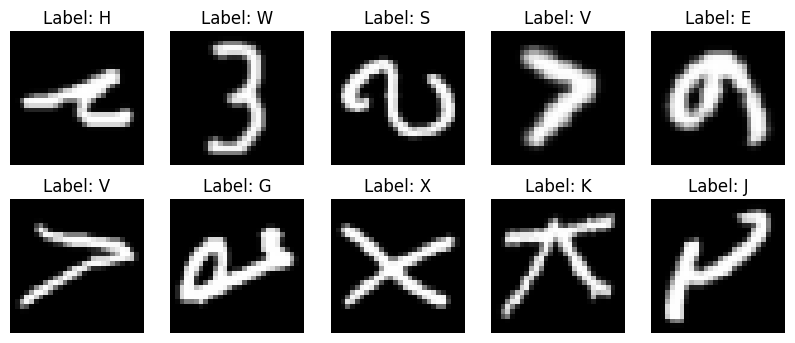

In [15]:
# Show 10 random images
plt.figure(figsize=(10, 4))
for i in range(10):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Label: {chr(y_train[idx] + 65)}")  # 0=A, 1=B, ...
    plt.axis('off')
plt.show()

In [16]:
# import necessary libraries
import numpy as np
import cv2

In [17]:
# ORB detector for keypoint extraction
orb = cv2.ORB_create()

In [25]:
def extract_features(img):
    # Convert normalized image to uint8
    img_uint8 = (img * 255).astype(np.uint8)

    # Improve image contrast
    img_eq = cv2.equalizeHist(img_uint8)

    # Reduce noise
    img_blurred = cv2.GaussianBlur(img_eq, (3, 3), 0)

    # Feature 1: Sobel Edge Strength
    sobelx = cv2.Sobel(img_blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_blurred, cv2.CV_64F, 0, 1, ksize=3)

    sobel_mag = np.sqrt(sobelx**2 + sobely**2)

    f1 = np.mean(sobel_mag) / 255.0

    # Feature 2: Connected Components
    _, binary = cv2.threshold(
        img_blurred,
        80,
        255,
        cv2.THRESH_BINARY
    )

    num_labels, _ = cv2.connectedComponents(binary)

    f2 = num_labels - 1

    # Feature 3: LBP Texture
    lbp = np.zeros_like(img_blurred, dtype=np.float32)

    for i in range(1, 27):
        for j in range(1, 27):

            center = img_blurred[i, j]

            neighbors = [
                img_blurred[i-1, j-1],
                img_blurred[i-1, j],
                img_blurred[i-1, j+1],
                img_blurred[i, j-1],
                img_blurred[i, j+1],
                img_blurred[i+1, j-1],
                img_blurred[i+1, j],
                img_blurred[i+1, j+1]
            ]

            binary_vals = [
                1 if n >= center else 0
                for n in neighbors
            ]

            lbp[i, j] = sum(
                val * (2 ** k)
                for k, val in enumerate(binary_vals)
            )

    f3 = np.mean(lbp) / 255.0

    # Feature 4: Canny Edge Density
    canny = cv2.Canny(img_blurred, 50, 150)

    f4 = np.mean(canny) / 255.0

    # Feature 5: ORB Keypoints
    keypoints = orb.detect(img_blurred, None)

    f5 = len(keypoints)

    # Feature 6: Mean Intensity (after eq)
    f6 = np.mean(img_eq) / 255.0

    # Final feature vector
    feature_vector = np.array([
        f1,
        f2,
        f3,
        f4,
        f5,
        f6
    ])

    return feature_vector

In [26]:
"""sample_features = extract_features(X_train[0])

print("Sample Feature Vector:")
print(sample_features)"""

Sample Feature Vector:
[0.935045   1.         0.52599543 0.19260204 0.         0.21189976]


In [27]:
print("Extracting features from training images...")

X_train_features = []

for i in range(len(X_train)):

    vec = extract_features(X_train[i])

    X_train_features.append(vec)

    if (i + 1) % 5000 == 0:
        print(f"Processed {i+1}/{len(X_train)} images")

Extracting features from training images...
Processed 5000/15000 images
Processed 10000/15000 images
Processed 15000/15000 images


In [28]:
X_train_features = np.array(X_train_features)

print("Training Feature Matrix Shape:")
print(X_train_features.shape)

Training Feature Matrix Shape:
(15000, 6)


In [30]:
X_test_features = [
    extract_features(img)
    for img in X_test
]

X_test_features = np.array(X_test_features)

print("Test Feature Matrix Shape:")
print(X_test_features.shape)

Test Feature Matrix Shape:
(14800, 6)


In [31]:
np.save('X_train_features_5.npy', X_train_features)
np.save('X_test_features_5.npy', X_test_features)

np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print("Features Saved Successfully!")

Features Saved Successfully!


In [32]:
print("Sample Feature Vector:", X_train_features[0])

Sample Feature Vector: [0.935045   1.         0.52599543 0.19260204 0.         0.21189976]
